In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from brokenaxes import brokenaxes

import scienceplots
plt.style.use(['vibrant'])
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

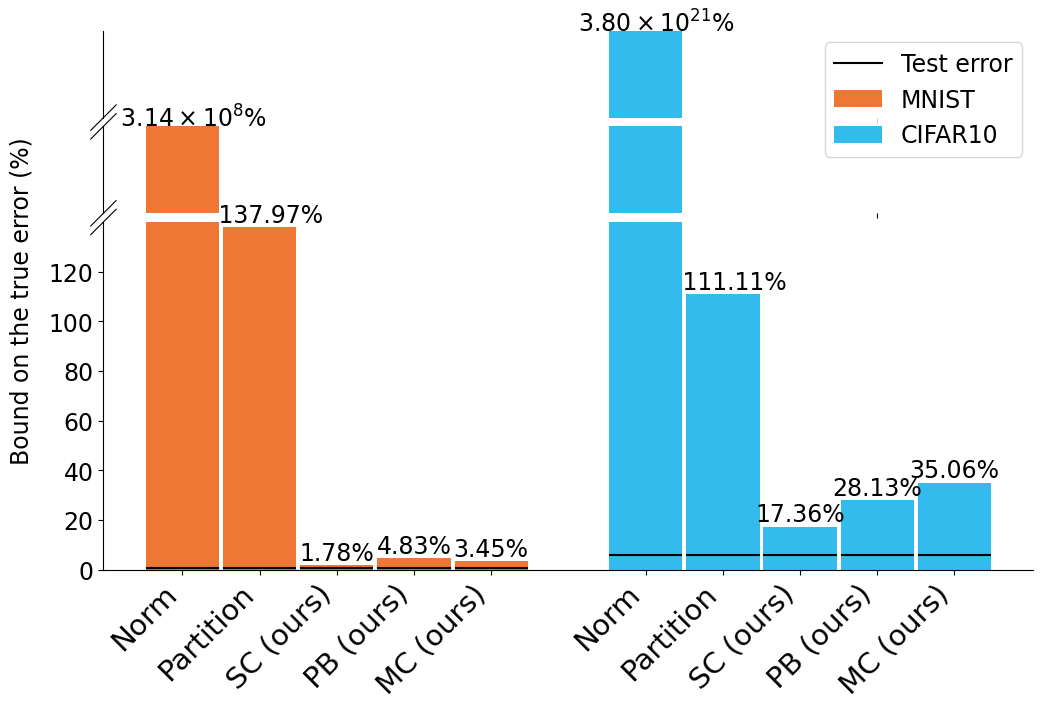

In [30]:
# import numpy as np
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes

SMALL_SIZE = 13
MEDIUM_SIZE = 15
BIGGER_SIZE = 17
plt.rc('font', size=21)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=21)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def myFormatter(val):
    if float(val) > 140:
        new_val = f"{val:.1e}"
        return new_val[:new_val.find("e")] + r'$\times 10^{' + str(int(new_val[new_val.find("+")+1:])) + r'}$%'
    elif float(val) > 100:
        return f"   {val:.2f}%"
    return f"{val:.2f}%"

# Use the actual extreme values now
my_results = np.array([[3.14e8, 3.80e21],
                       [137.97, 111.11], [1.78, 17.36], [4.83, 28.13], [3.45, 35.06]])

species = ['Norm', 'Partition', r'SC (ours)', r'PB (ours)', r'MC (ours)']

x = np.arange(len(species))  # the label locations
width = 0.95  # the width of the bars
multiplier = 0.5
full_offset = 6

# Create broken axes - adjust these ranges based on your data
fig = plt.figure(figsize=(12, 7), d)
bax = brokenaxes(
    ylims=((0, 140), (1e8, 4e8), (1e21, 4e21)),  # Three ranges: normal, MNIST extreme, CIFAR10 extreme
    hspace=.05,  # Space between broken axis segments
    despine=True,
    fig=fig, 
    height_ratios=[1, 1, 4]
)

# Plot bars for MNIST
bax.bar(x[0], 140, color=colors[0], label='MNIST', width=width)
bax.bar(x[0], 3.14e8, bottom=1e8, color=colors[0], width=width)

rects2 = bax.bar(x[1:], my_results[1:, 0], color=colors[0], width=width)

for i, rect in enumerate(rects2[0]):
    height = my_results[i+1, 0]
    bax.text(rect.get_x() + rect.get_width()/2., height,
             myFormatter(height),
             ha='center', va='bottom', fontsize=BIGGER_SIZE)

# Plot bars for CIFAR10
# rects3 = bax.bar(x[0] + full_offset, my_results[0, 1], color=colors[2], label="CIFAR10", width=width)

bax.bar(x[0] + full_offset, 140, color=colors[2], label="CIFAR10", width=width)
bax.bar(x[0] + full_offset,4e8,  bottom=1e8, color=colors[2], width=width)
bax.bar(x[0] + full_offset, 3.80e21, bottom=1e21, color=colors[2],width=width)
rects4 = bax.bar(x[1:] + full_offset, my_results[1:, 1], color=colors[2], width=width)

for i, rect in enumerate(rects4[0]):
    height = my_results[i+1, 1]
    bax.text(rect.get_x() + rect.get_width()/2., height,
             myFormatter(height),
             ha='center', va='bottom', fontsize=BIGGER_SIZE)

# Add labels for extreme values
bax.text(x[0], 4e8*0.95, r"   $3.14 \times 10^{8}$%", 
         ha='center', va='bottom', fontsize=BIGGER_SIZE)
bax.text(x[0] + full_offset, my_results[0, 1] * 1.001, r"   $3.80 \times 10^{21}$%", 
         ha='center', va='bottom', fontsize=BIGGER_SIZE)
  
# Add horizontal lines for test error (adjust positions as needed)
# For the lower subplot (0-100 range) - this is axs[0]
bax.axhline(y=0.5, color='black', linestyle="-", xmin=0.047, xmax=0.123, label='Test error')
bax.axs[-1].axhline(y=0.5, color='black', linestyle="-", xmin=0.13, xmax=0.206)
bax.axs[-1].axhline(y=0.5, color='black', linestyle="-", xmin=0.212, xmax=0.289)
bax.axs[-1].axhline(y=0.5, color='black', linestyle="-", xmin=0.295, xmax=0.373)
bax.axs[-1].axhline(y=0.5, color='black', linestyle="-", xmin=0.379, xmax=0.455)

bax.axs[-1].axhline(y=5.84, color='black', linestyle="-", xmin=0.545, xmax=0.621)
bax.axs[-1].axhline(y=5.84, color='black', linestyle="-", xmin=0.627, xmax=0.705)
bax.axs[-1].axhline(y=5.84, color='black', linestyle="-", xmin=0.710, xmax=0.788)
bax.axs[-1].axhline(y=5.84, color='black', linestyle="-", xmin=0.794, xmax=0.871)
bax.axs[-1].axhline(y=5.84, color='black', linestyle="-", xmin=0.877, xmax=0.953)

# Add ylabel
bax.set_ylabel("Bound on the true error (%)", labelpad=50)

# Add legend
bax.legend(loc='upper right', ncols=1)

# Set x-axis labels - need to set on each individual axis
all_x_positions = list(x) + list(x + full_offset)
all_labels = 2 * species

# Set ticks and labels on the bottom-most axis (which handles the x-axis)
# In brokenaxes, axs[-1] is the bottom subplot
bax.axs[-1].set_xticks(all_x_positions)
bax.axs[-1].set_xticklabels(all_labels, rotation=45, ha='right')

# Also set the same ticks on all axes to ensure proper alignment
for ax in bax.axs:
    ax.set_xticks(all_x_positions)
    if ax != bax.axs[-1]:
        ax.set_xticklabels([])  # Hide labels on non-bottom axes
        
target_idx = 2

# --- Apply y-tick visibility and ticks only to the (0, 100) axis ---
for i, ax in enumerate(bax.axs):
    is_target = (i == target_idx)
    if is_target:
        # Ensure ticks and labels are actually drawn on this axis
        ax.tick_params(axis='y', which='both', left=True, labelleft=True)
        # Set the ticks and labels you want
        yticks = [0, 20, 40, 60, 80, 100, 120]
        ax.set_yticks(yticks)
        ax.set_yticklabels([str(t) for t in yticks])
        # (Optional) keep the exact ylim in case anything shifted
        # ax.set_ylim(0, 100)
    else:
        # Hide ticks/labels on other segments
        ax.set_yticks([])
        ax.set_yticklabels([])
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)

plt.savefig('./results/introduction_plot_broken_axes.pdf', bbox_inches='tight')
# plt.show()